# Week 6 Lab

## 1) Exploring neural networks

### 1.1) Simple separable data set

Here's a very simple data set.

```python
X = np.array([[2, 3, 9, 12],
              [5, 2, 6, 5]])
Y = np.array([[1, 0, 1, 0]])
```
The code below runs a very simple neural network composed of a single sigmoid unit with two inputs, using negative log likelihood (NLL) loss:

<div align="center">
    <img src="../assets/labs/1_1_1.png" alt="1_1_1" style="border-radius: 10px" />
</div>

The function `t1` in the code box below plots the classifier found after training for the specified number of iterations with the specified "learning rate" (step size). The classifier predicts label $+1$ if the output is greater than $0.5$ and label $0$ otherwise -- remember that the range of the sigmoid function is $(0,1)$.


#### 1.1.A) What is the shape of the separator produced by this network? Explain.

The shape of the separator is a **straight line**.

**Explanation:**
Although the network uses a sigmoid activation function (which outputs a value between 0 and 1), the decision boundary is determined by the threshold where the prediction switches classes. The problem states that the network predicts +1 if the output is greater than 0.5.

The sigmoid function equals 0.5 exactly when its input $z$ is 0. 
Since the input $z$ is the linear combination of the features, the decision boundary is formed by the equation:
$w_1x_1 + w_2x_2 + b = 0$

In a 2D space (because we have two input features $x_1$ and $x_2$), this equation defines a straight line. Therefore.

#### 1.1.B) Are you able to get relatively consistent 100% accuracy with some combination of iters and learning rate lr?

**Yes**.

This specific dataset is perfectly linearly separable. Because a single-neuron network with a sigmoid activation produces a linear decision boundary (a straight line), it is structurally capable of separating these classes. With a well-tuned learning rate and a sufficient number of iterations, the gradient descent algorithm will find this optimal boundary and consistently achieve 100% accuracy on the training set.

<div align="center">
    <img src="../assets/labs/3_1_B.png" alt="3_1_B" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/labs/2_1_B.png" alt="2_1_B" style="border-radius: 10px" />
</div>

### 1.2) Not-XOR

The XOR dataset is a classic example showing the need for more than one layer of non-linear units. Here, we will consider a function outputting the negation of XOR, Not-XOR:

```python
X = np.array([[0, 1, 0, 1],
              [0, 1, 1, 0]])
Y = np.array([[1, 1, 0, 0]])
```

#### 1.2.A) Draw a plot showing the locations of these data points in $x_{1}, x_{2}$ coordinate space, with the corresponding labels. Now consider a network with no hidden layers as in part 1.1 above, which just has input units connected (via weights) to an output sigmoid unit. Can this network learn a separator for the given dataset? Explain.

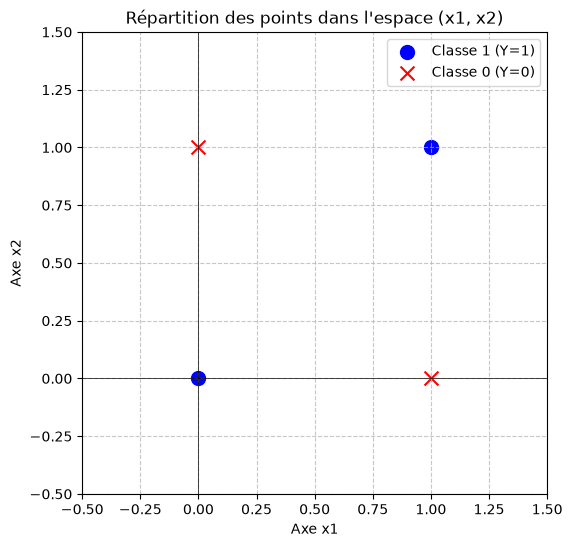

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0, 1, 0, 1],
              [0, 1, 1, 0]])
Y = np.array([[1, 1, 0, 0]])

x1 = X[0, :]
x2 = X[1, :]
labels = Y[0, :]

plt.figure(figsize=(6, 6))

plt.scatter(x1[labels == 1], x2[labels == 1], 
            color='blue', marker='o', s=100, label='Classe 1 (Y=1)')

plt.scatter(x1[labels == 0], x2[labels == 0], 
            color='red', marker='x', s=100, label='Classe 0 (Y=0)')

plt.xlabel('Axe x1')
plt.ylabel('Axe x2')
plt.title('Répartition des points dans l\'espace (x1, x2)')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

**No**.

This network cannot learn a valid separator because the dataset is **not linearly separable**. This specific arrangement of data points corresponds to the classic XOR/XNOR problem (the points of the same class are on opposite diagonal corners). As established in part 1.1, a single sigmoid unit without hidden layers can only produce a linear decision boundary (a single straight line). It is geometrically impossible to draw a single straight line that separates the class 1 points at (0,0) and (1,1) from the class 0 points at (0,1) and (1,0).

<div align="center">
    <img src="../assets/labs/4_1_2_B.png" alt="4_1_2_B" style="border-radius: 10px" />
</div>

### How it Works (Geometric Explanation)
In our earlier $(x_1, x_2)$ plot, the data forms a diagonal cross (the Not-XOR problem). Class 1 points are at (0,0) and (1,1), while class 0 points are at (0,1) and (1,0). 
*   The first hidden unit draws a decision boundary that activates only for the class 1 point at (0,0).
*   The second hidden unit draws a decision boundary that activates only for the class 1 point at (1,1).

By passing the data through the ReLU activation, the original 2D space is "folded". In this new hidden representation, both class 0 points are pushed to (0,0), while the class 1 points become linearly separable. The output sigmoid unit can now easily draw a single straight line to isolate them.

### Why a Smaller Network Won't Work
A smaller network implies using only **1 hidden unit**. A single neuron computes a single linear combination, which geometrically translates to drawing one single straight line. Because the Not-XOR data points of the same class are on opposite diagonal corners, it is mathematically impossible to separate them with just one line. Two hidden units (providing two lines) are the absolute minimum required to bound the space.